# Resultados del piloto Random Forest (jets `pT > 20 GeV`)

## Conclusión ejecutiva

Este piloto de una muestra ROOT por clase separa jets `b` de `uds` con una discriminación consistente en validación y prueba. El punto de operación se eligió exclusivamente en validación para una eficiencia objetivo de `b` del 70%; las métricas de prueba se presentan más adelante y se cargan directamente desde el artefacto del entrenamiento. El resultado es una línea base útil, no una medición final de desempeño físico.

## Mapa de reproducción

| Etapa | Entrada | Proceso | Salida verificable |
|---|---|---|---|
| 1 | ROOT de `QCD_bbbar` y `QCD_uds` | `ml/build_dataset.py` | parquet de train/val/test y manifest |
| 2 | parquet y manifest | `ml/train_rf.py` | modelo, métricas, puntuaciones indexadas e importancias |
| 3 | métricas, parquet y CSV indexados | este cuaderno | validaciones y figuras reproducidas |

El cuaderno lee `outputs/pilot_gt20` y `outputs/rf_pilot_gt20` mediante rutas relativas al repositorio. Las rutas absolutas de los ROOT se conservan únicamente como procedencia registrada en el manifest.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve
from IPython.display import display

DATASET_DIR = Path("outputs/pilot_gt20")
RF_DIR = Path("outputs/rf_pilot_gt20")
ARTIFACTS = {
    "manifest": DATASET_DIR / "dataset_manifest.json",
    "train": DATASET_DIR / "train.parquet",
    "val": DATASET_DIR / "val.parquet",
    "test": DATASET_DIR / "test.parquet",
    "metrics": RF_DIR / "rf_metrics.json",
    "scores": RF_DIR / "rf_test_scores.csv",
    "importance": RF_DIR / "rf_feature_importance.csv",
}
missing = [str(path) for path in ARTIFACTS.values() if not path.is_file()]
if missing:
    raise FileNotFoundError("Faltan artefactos requeridos (ejecute desde la raíz del repositorio):\n" + "\n".join(missing))

with ARTIFACTS["manifest"].open(encoding="utf-8") as handle:
    manifest = json.load(handle)
with ARTIFACTS["metrics"].open(encoding="utf-8") as handle:
    metrics = json.load(handle)
train = pd.read_parquet(ARTIFACTS["train"])
val = pd.read_parquet(ARTIFACTS["val"])
test = pd.read_parquet(ARTIFACTS["test"])
scores = pd.read_csv(ARTIFACTS["scores"])
importance = pd.read_csv(ARTIFACTS["importance"])
print("Artefactos cargados correctamente desde rutas relativas.")

Artefactos cargados correctamente desde rutas relativas.


## Procedencia y configuración del conjunto

La tabla siguiente se deriva del manifest. La selección de fuentes corresponde a una sola muestra ROOT de `QCD_bbbar` y una de `QCD_uds`; no representa una mezcla completa de procesos.

In [2]:
provenance = pd.DataFrame([
    ("Fuentes ROOT", "\n".join(f"{item['label']}: {item['file']}" for item in manifest["files"])),
    ("Región y expresión de pT", f"{manifest['pt_region']}: {manifest['pt_expression']}"),
    ("Cono del jet", manifest["generator_settings"]["jet_cone"]),
    ("Máximo de jets por evento", manifest["generator_settings"]["max_jets_per_event"]),
    ("Semilla del generador", manifest["generator_settings"]["seed"]),
    ("Método de división", manifest["split"]["method"]),
    ("Semilla de división", manifest["split"]["seed"]),
], columns=["Campo", "Valor"])
display(provenance)

,Campo,Valor
0,Fuentes ROOT,b: /home/juanm/Documents/Libros/btag/QCD_bbbar...
1,Región y expresión de pT,gt20: jet_pt > 20
2,Cono del jet,0.4
3,Máximo de jets por evento,4
4,Semilla del generador,42
5,Método de división,event_grouped_stratified
6,Semilla de división,42


## Composición y particiones

Los conteos se recalculan desde los parquet y se contrastan con el manifest antes de mostrarse.

In [3]:
splits = {"train": train, "val": val, "test": test}
rows = []
for name, frame in splits.items():
    observed = frame["sample_label"].value_counts().to_dict()
    expected = manifest["sample_counts"][name]
    assert {label: int(count) for label, count in observed.items()} == expected, f"Conteos incompatibles en {name}"
    assert len(frame) == manifest[f"n_{name}_jets"], f"Total incompatible en {name}"
    assert frame["global_event_id"].nunique() == manifest[f"n_{name}_events"], f"Eventos incompatibles en {name}"
    rows.append({"Partición": name, "Jets": len(frame), "b": observed.get("b", 0), "uds": observed.get("uds", 0), "Eventos": frame["global_event_id"].nunique()})
summary = pd.DataFrame(rows).set_index("Partición")
assert int(summary["Jets"].sum()) == manifest["n_full_jets"]
display(summary)
print(f"Total: {manifest['n_full_jets']:,} jets; b={manifest['sample_counts']['full']['b']:,}; uds={manifest['sample_counts']['full']['uds']:,}.")

,Jets,b,uds,Eventos
Partición,,,,
train,95505,44026,51479,57430
val,20406,9382,11024,12306
test,20568,9501,11067,12307


Total: 136,479 jets; b=62,909; uds=73,570.


## Validación directa de `pT`

La condición aplicada es estricta: `jet_pt > 20`. Se comprueba sobre los tres parquet, no solo sobre el texto del manifest. El intento `lt20` con estas fuentes seleccionadas no produjo filas y terminó de forma controlada; por ello no existe un modelo `lt20` para este piloto.

In [4]:
all_jets = pd.concat([train, val, test], ignore_index=True)
pt_min = float(all_jets["jet_pt"].min())
pt_max = float(all_jets["jet_pt"].max())
violations = int((all_jets["jet_pt"] <= 20).sum())
pt_check = pd.DataFrame([{
    "Mínimo pT [GeV]": pt_min,
    "Máximo pT [GeV]": pt_max,
    "Jets con pT <= 20 GeV": violations,
    "Condición verificada": violations == 0,
}])
display(pt_check)
assert violations == 0, "Hay jets que incumplen la selección estricta pT > 20"
assert manifest["pt_expression"] == "jet_pt > 20"

,Mínimo pT [GeV],Máximo pT [GeV],Jets con pT <= 20 GeV,Condición verificada
0,21.483398,306.623047,0,True


## Independencia de eventos entre particiones

Un mismo `global_event_id` no debe aparecer en más de una partición. Esta comprobación protege contra fuga de información entre entrenamiento, validación y prueba.

In [5]:
event_sets = {name: set(frame["global_event_id"].unique()) for name, frame in splits.items()}
overlap_rows = []
for left, right in (("train", "val"), ("train", "test"), ("val", "test")):
    overlap = len(event_sets[left] & event_sets[right])
    overlap_rows.append({"Par de particiones": f"{left} / {right}", "Eventos compartidos": overlap})
    assert overlap == 0, f"Fuga de eventos entre {left} y {right}"
display(pd.DataFrame(overlap_rows))
print("Las tres particiones son disjuntas por evento.")

,Par de particiones,Eventos compartidos
0,train / val,0
1,train / test,0
2,val / test,0


Las tres particiones son disjuntas por evento.


## Modelo y resumen de métricas

Las métricas de titular se leen de `rf_metrics.json`; el cuaderno no las codifica en la lógica de análisis. El umbral se fijó con validación y se aplicó sin ajuste al conjunto de prueba.

In [6]:
configuration = pd.DataFrame(metrics["rf_configuration"].items(), columns=["Parámetro", "Valor"])
display(configuration)
operating = metrics["operating_point"]
test_metrics = operating["test_metrics"]
metric_summary = pd.DataFrame([{
    "AUC validación": metrics["validation_auc"],
    "AUC prueba": metrics["test_auc"],
    "Eficiencia b objetivo": operating["target_b_efficiency"],
    "Umbral (validación)": test_metrics["threshold"],
    "Eficiencia b (prueba)": test_metrics["b_efficiency"],
    "Mistag uds (prueba)": test_metrics["uds_mistag"],
    "Rechazo uds (prueba)": test_metrics["uds_rejection"],
}])
display(metric_summary.round(6))
assert len(manifest["schema"]["feature_columns"]) == metrics["feature_count"]

,Parámetro,Valor
0,seed,42
1,n_estimators,80
2,max_depth,8
3,min_samples_leaf,20
4,class_weight,balanced
5,n_jobs,-1


,AUC validación,AUC prueba,Eficiencia b objetivo,Umbral (validación),Eficiencia b (prueba),Mistag uds (prueba),Rechazo uds (prueba)
0,0.887871,0.881608,0.7,0.552427,0.697716,0.122526,8.161504


## Distribuciones de puntuación por muestra

La figura se genera a partir de `rf_test_scores.csv`, que conserva la etiqueta de muestra y el identificador del evento para cada puntuación de prueba.

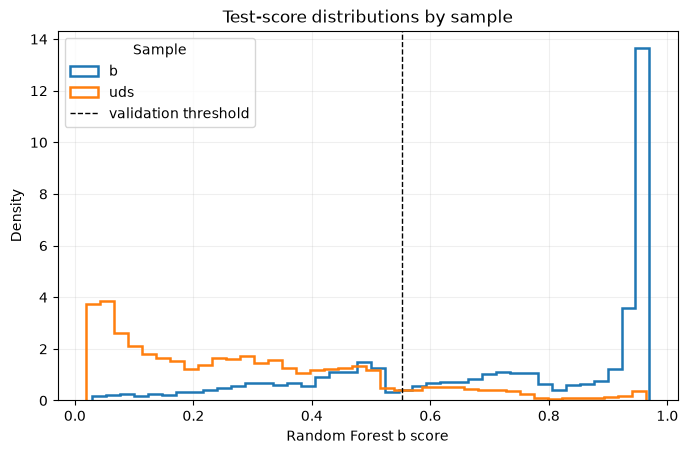

In [7]:
required_score_columns = {"global_event_id", "sample_label", "is_b", "score_rf"}
missing_score_columns = required_score_columns - set(scores.columns)
if missing_score_columns:
    raise ValueError(f"El CSV de puntuaciones no contiene columnas requeridas: {sorted(missing_score_columns)}")
assert len(scores) == len(test)
assert scores["global_event_id"].equals(test["global_event_id"].reset_index(drop=True))

fig, ax = plt.subplots(figsize=(8, 4.8))
for label in sorted(scores["sample_label"].unique()):
    ax.hist(scores.loc[scores["sample_label"] == label, "score_rf"], bins=40, density=True, histtype="step", linewidth=1.8, label=label)
ax.axvline(test_metrics["threshold"], color="black", linestyle="--", linewidth=1, label="validation threshold")
ax.set(xlabel="Random Forest b score", ylabel="Density", title="Test-score distributions by sample")
ax.legend(title="Sample")
ax.grid(alpha=0.2)
plt.show()

## ROC y rechazo de fondo

La curva se reconstruye desde las puntuaciones indexadas y `is_b`. El eje vertical es el rechazo de fondo `1 / FPR`; los puntos con FPR cero no se representan porque su rechazo es indefinido en escala finita.

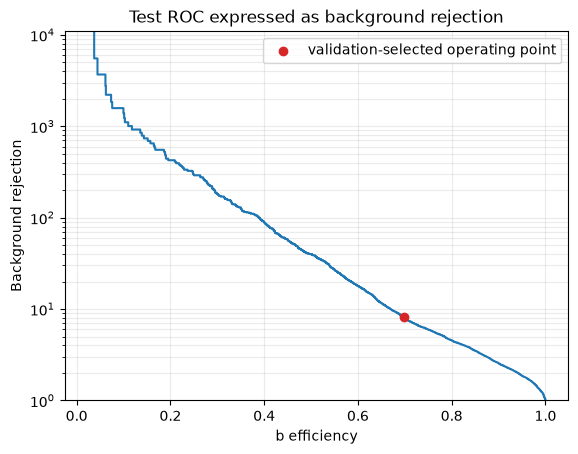

In [8]:
fpr, tpr, _ = roc_curve(scores["is_b"], scores["score_rf"])
rejection = np.divide(1, fpr, out=np.full_like(fpr, np.nan), where=fpr > 0)
fig, ax = plt.subplots(figsize=(6.5, 4.8))
ax.semilogy(tpr, rejection, color="tab:blue")
ax.scatter([test_metrics["b_efficiency"]], [test_metrics["uds_rejection"]], color="tab:red", zorder=3, label="validation-selected operating point")
ax.set(xlabel="b efficiency", ylabel="Background rejection", title="Test ROC expressed as background rejection", ylim=(1, np.nanmax(rejection)))
ax.grid(True, which="both", alpha=0.25)
ax.legend()
plt.show()

## Importancia de variables

La importancia de Random Forest describe contribución predictiva dentro de este modelo y este conjunto; no demuestra causalidad ni sustituye una evaluación de sistemáticas. Las variables se agrupan para interpretar el patrón físico de forma más accesible.

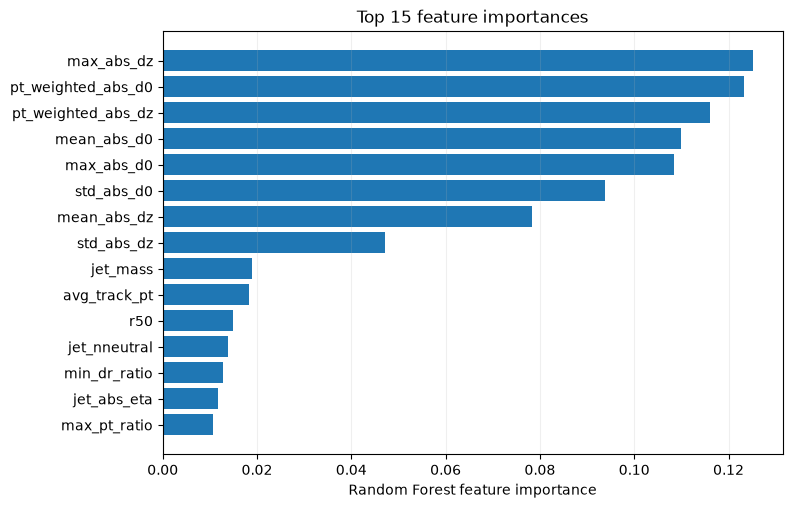

,feature,importance
0,max_abs_dz,0.125233
1,pt_weighted_abs_d0,0.123183
2,pt_weighted_abs_dz,0.116097
3,mean_abs_d0,0.109999
4,max_abs_d0,0.108384
5,std_abs_d0,0.093701
6,mean_abs_dz,0.078367
7,std_abs_dz,0.047244
8,jet_mass,0.018874
9,avg_track_pt,0.018240


,group,importance
0,Impact parameters,0.802206
2,Track content / shape,0.134735
1,Jet kinematics,0.063058


In [9]:
top15 = importance.head(15).copy()
fig, ax = plt.subplots(figsize=(8, 5.5))
ordered = top15.sort_values("importance")
ax.barh(ordered["feature"], ordered["importance"], color="tab:blue")
ax.set(xlabel="Random Forest feature importance", title="Top 15 feature importances")
ax.grid(axis="x", alpha=0.2)
plt.show()
display(top15.round({"importance": 6}))

impact_parameters = {"mean_abs_d0", "max_abs_d0", "std_abs_d0", "mean_abs_dz", "max_abs_dz", "std_abs_dz", "pt_weighted_abs_d0", "pt_weighted_abs_dz"}
jet_kinematics = {"jet_pt", "jet_eta", "jet_abs_eta", "jet_mass", "jet_ncharged", "jet_nneutral"}
def feature_group(feature):
    if feature in impact_parameters:
        return "Impact parameters"
    if feature in jet_kinematics:
        return "Jet kinematics"
    return "Track content / shape"
grouped = importance.assign(group=importance["feature"].map(feature_group)).groupby("group", as_index=False)["importance"].sum().sort_values("importance", ascending=False)
display(grouped.round({"importance": 6}))

### Interpretación física agrupada

- **Impact parameters:** las variables basadas en `d0` y `dz` concentran la mayor importancia. En este piloto, el patrón es compatible con la señal esperada de trazas desplazadas en jets `b`.
- **Jet kinematics:** incluyen `jet_pt`, masa, pseudorapidez y multiplicidades. Su contribución es secundaria; en particular, `jet_pt` tiene una importancia cercana a 0.008 en el CSV.
- **Track content / shape:** las sumas, razones y radios de trazas aportan información complementaria, pero no dominan la separación observada.

## Alcance de las conclusiones

### Se puede concluir

- Para estas dos fuentes y la selección estricta `pT > 20 GeV`, el Random Forest ofrece una línea base reproducible con separación útil entre `b` y `uds`.
- La selección del umbral se realizó en validación y la evaluación final se hizo en eventos de prueba disjuntos.
- Las variables de parámetro de impacto dominan la importancia interna del modelo en este piloto.

### No se puede concluir

- No es una medición representativa de todos los ROOT disponibles ni de una producción completa.
- No evalúa clases `c` o `g`, incertidumbres sistemáticas, calibración del score ni robustez frente a otras condiciones de simulación.
- No permite extraer conclusiones para `pT < 20 GeV`: las fuentes seleccionadas no aportaron filas en esa región y no existe un modelo `lt20` asociado.

## Comandos exactos para repetir el piloto

Ejecutar desde la raíz del repositorio. Este es un piloto de **un archivo por clase**; una corrida completa requiere un constructor en streaming y más memoria.

```bash
python ml/build_dataset.py \
  --data-dir /home/juanm/singularity-tmp/opencode/btagginghep-rf-pilot/input \
  --output-dir outputs/pilot_gt20 \
  --pt-region gt20

python ml/train_rf.py \
  --dataset-dir outputs/pilot_gt20 \
  --output-dir outputs/rf_pilot_gt20 \
  --seed 42 \
  --n-estimators 80 \
  --max-depth 8 \
  --min-samples-leaf 20 \
  --target-efficiency 0.70
```

Para reejecutar este cuaderno y conservar las salidas embebidas:

```bash
/home/juanm/singularity-tmp/opencode/btagginghep-rf-pilot/venv/bin/python -c "from pathlib import Path; import nbformat; from nbclient import NotebookClient; p=Path('notebooks/random-forest-pilot-results.ipynb'); n=nbformat.read(p, as_version=4); NotebookClient(n, timeout=600, kernel_name='python3').execute(cwd='.'); nbformat.write(n, p)"
```